Time to Descend: 2.3219999999998553 s
The Maximum Force Due to Motor Torque on Wheel = 28.2528 N


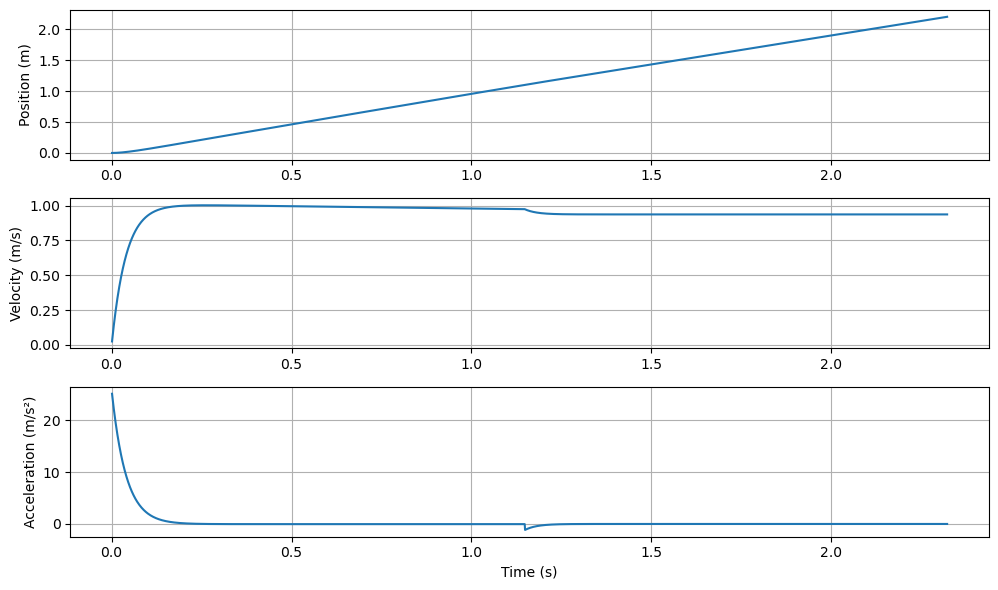

In [6]:
import numpy as np
import matplotlib.pyplot as plt

Motor_Stall_Torque = 6300 * 0.001 * 9.81 * 0.01 # Nm
No_Load_Speed_RPM = 336 # RPM
Gear_Ratio = 1
Device_Mass = 1.5 # kg
Chain_Mass_Per_M = 0.155 # kg/m
Wheel_Friction = 0.7
Drive_Wheel_Radius = 0.0175 # m
No_Load_Speed_rad = (No_Load_Speed_RPM*2*np.pi) / 60
Motor_Curve_Gradient = Motor_Stall_Torque / No_Load_Speed_rad
Position = 0 # relative to starting distance to ground
Velocity = 0 # ms^-1
Acceleration = 0 # ms^-2
Time = 0 # s
Time_Step = 0.001 # s
g=9.81
Height = 2.2 # m
Mechanical_Efficiency = 0.8
Chain_Drop_Height = 1.1 # m

Chain_Dropped = False

time = []
position = []
velocity = []
acceleration = []
torque = []
force = []

while Position <= Height:

    Height_Above_Ground = Height - Position

    if not Chain_Dropped and Height_Above_Ground <= Chain_Drop_Height:
        Chain_Dropped = True
    
    Drive_Wheel_Angular_Velocity = (Velocity / Drive_Wheel_Radius)
    
    Motor_Angular_Velocity = Drive_Wheel_Angular_Velocity * Gear_Ratio
    
    Motor_Torque = Motor_Stall_Torque - (Motor_Curve_Gradient * Motor_Angular_Velocity)
    
    Drive_Wheel_Torque = Gear_Ratio * Mechanical_Efficiency * Motor_Torque
    
    Force_Due_To_Motor_Torque = Drive_Wheel_Torque / Drive_Wheel_Radius

    if Chain_Dropped:
        Overall_Mass = Device_Mass
    else:
        Overall_Mass = (Device_Mass + (Chain_Mass_Per_M * Height_Above_Ground))
    
    Overall_Weight = Overall_Mass * g

    Net_Force = Force_Due_To_Motor_Torque + Overall_Weight  

    Acceleration = Net_Force / Overall_Mass
    
    Velocity = Velocity + (Acceleration * Time_Step)
    
    Position = Position + (Velocity * Time_Step)

    Time = Time + Time_Step
    
    time.append(Time)
    position.append(Position)
    velocity.append(Velocity)
    acceleration.append(Acceleration)
    torque.append(Motor_Torque)
    force.append(Force_Due_To_Motor_Torque)

print("Time to Descend:",Time,"s")
print("The Maximum Force Due to Motor Torque on Wheel =",max(force),"N")

plt.figure(figsize=(10,6))

plt.subplot(311)
plt.plot(time, position)
plt.ylabel("Position (m)")
plt.grid()

plt.subplot(312)
plt.plot(time, velocity)
plt.ylabel("Velocity (m/s)")
plt.grid()

plt.subplot(313)
plt.plot(time, acceleration)
plt.ylabel("Acceleration (m/s²)")
plt.xlabel("Time (s)")
plt.grid()

plt.tight_layout()
plt.show()